<a href="https://colab.research.google.com/github/pichimalokam123/cric/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas
!Pip install matplotlib
!pip install seaborn
!pip install scikit_learn
!pip install openpyxl

/bin/bash: line 1: Pip: command not found


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [7]:
df=pd.read_excel("/content/online_retail_II[2].xlsx", sheet_name=0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [8]:
cleaned_df=df.copy()

In [10]:
cleaned_df["Invoice"]=cleaned_df["Invoice"].astype("str")
mask=(
    cleaned_df["Invoice"].str.match("^\\d{6}$")==True
)
cleaned_df=cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [13]:
cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")
mask=(
    (cleaned_df["StockCode"].str.match("^\\d{5}$")==True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]$")==True)
    | (cleaned_df["StockCode"].str.match("^PADS$")==True)
)
cleaned_df=cleaned_df[mask]
cleaned_df

<ipython-input-13-08d31f016c7e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [14]:
cleaned_df.dropna(subset=["Customer ID"], inplace=True)
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [32]:
cleaned_df=cleaned_df[cleaned_df["Price"]>0.0]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [33]:
len(cleaned_df)/len(df)

0.7717547068193453

In [34]:
cleaned_df["SalesLineTotal"]=cleaned_df["Quantity"]*cleaned_df["Price"]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [35]:
from inspect import FrameInfo
aggregated_df=cleaned_df.groupby(by="Customer ID", as_index=False)\
              .agg(
                  MonetryValue=("SalesLineTotal", sum),
                  Frequency=("Invoice", "nunique"),
                  LastInvoiceDate=("InvoiceDate", "max")
              )
aggregated_df.head(5)

<ipython-input-35-8c0e3199f15c>:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg(


,Customer ID,MonetryValue,Frequency,LastInvoiceDate
0,12346.0,163.41,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [36]:
max_invoice_date=aggregated_df["LastInvoiceDate"].max()
max_invoice_date

Timestamp('2010-12-09 20:01:00')

In [37]:
aggregated_df["Recency"]=(max_invoice_date-aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,163.41,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17
4281,18284.0,411.68,1,2010-10-04 11:33:00,66
4282,18285.0,377.00,1,2010-02-17 10:24:00,295
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111


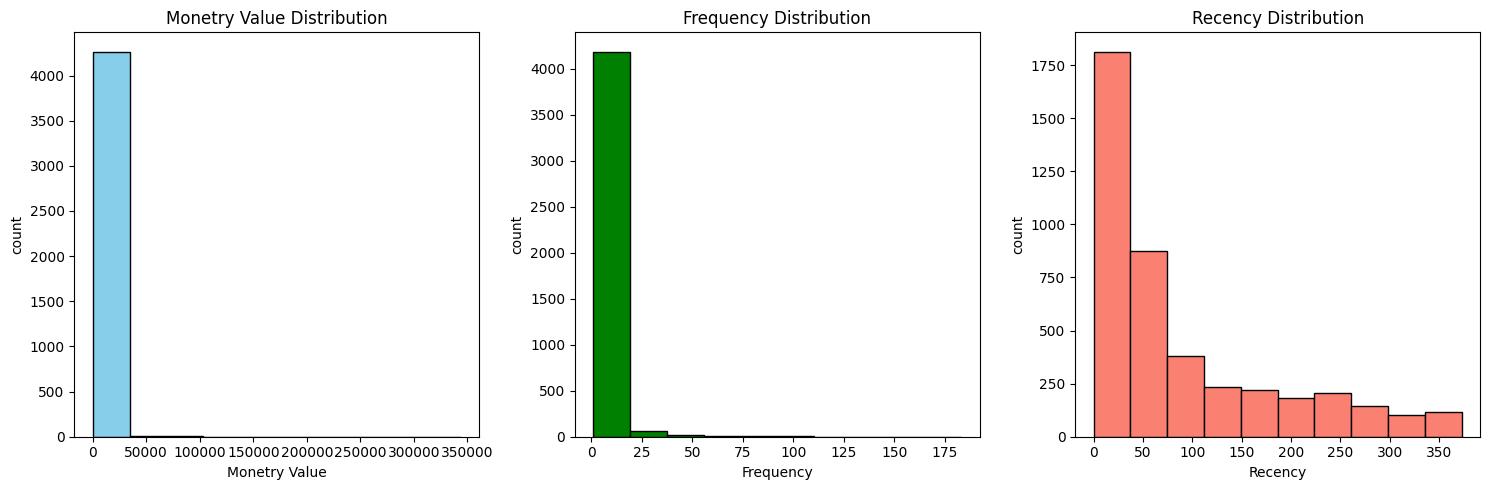

In [38]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(aggregated_df["MonetryValue"],bins=10, color="skyblue", edgecolor="black")
plt.title("Monetry Value Distribution")
plt.xlabel("Monetry Value")
plt.ylabel("count")

plt.subplot(1,3,2)
plt.hist(aggregated_df["Frequency"],bins=10, color="green", edgecolor="black")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("count")

plt.subplot(1,3,3)
plt.hist(aggregated_df["Recency"],bins=10, color="salmon", edgecolor="black")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("count")

plt.tight_layout()
plt.show()

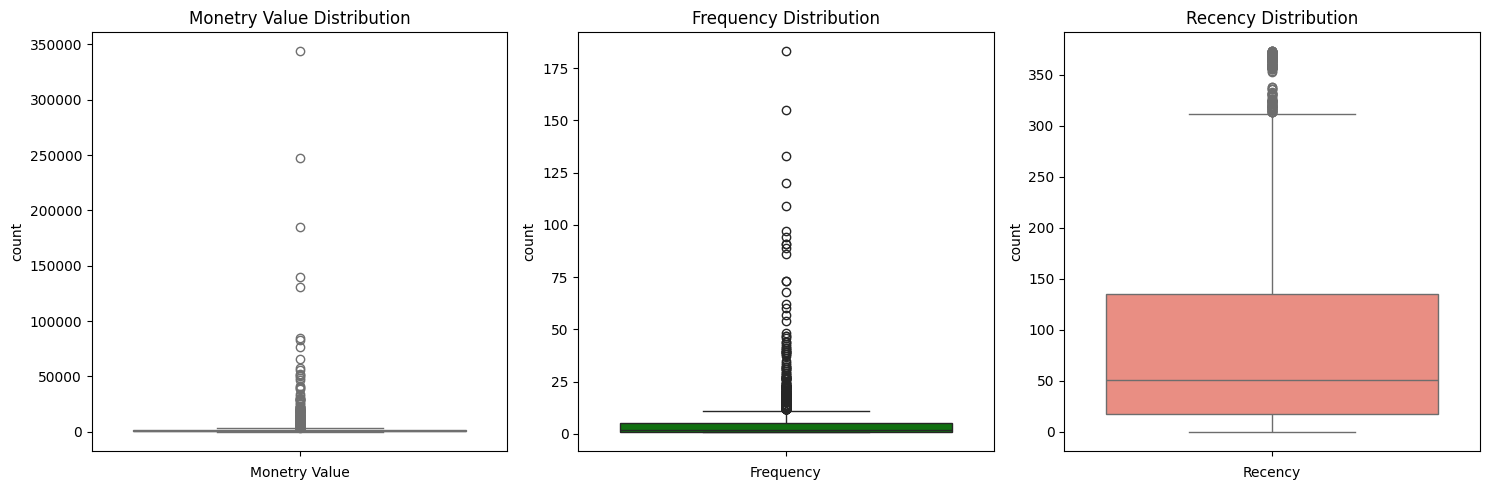

In [39]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(aggregated_df["MonetryValue"], color="skyblue")
plt.title("Monetry Value Distribution")
plt.xlabel("Monetry Value")
plt.ylabel("count")

plt.subplot(1,3,2)
sns.boxplot(aggregated_df["Frequency"], color="green")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("count")

plt.subplot(1,3,3)
sns.boxplot(aggregated_df["Recency"], color="salmon")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("count")

plt.tight_layout()
plt.show()

In [41]:
M_Q1=aggregated_df["MonetryValue"].quantile(0.25)
M_Q3=aggregated_df["MonetryValue"].quantile(0.75)
M_IQR=M_Q3-M_Q1
Monetary_outlier_df=aggregated_df[(aggregated_df["MonetryValue"]<(M_Q1-1.5*M_IQR)) | (aggregated_df["MonetryValue"]>(M_Q3+1.5*M_IQR))].copy()
Monetary_outlier_df.describe()

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency
count,421.000000,421.000000,421.000000,421,421.000000
mean,15107.242280,12150.487568,17.225653,2010-11-09 16:56:38.764845568,29.847981
min,12357.000000,3796.930000,1.000000,2009-12-10 18:03:00,0.000000
25%,13615.000000,4590.530000,8.000000,2010-11-08 15:42:00,3.000000
50%,15005.000000,6191.320000,12.000000,2010-11-26 12:44:00,13.000000
75%,16700.000000,10164.490000,18.000000,2010-12-06 11:06:00,31.000000
max,18260.000000,343764.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1731.684418,25632.405012,19.758275,NaN,51.563698


In [42]:
F_Q1=aggregated_df["Frequency"].quantile(0.25)
F_Q3=aggregated_df["Frequency"].quantile(0.75)
F_IQR=F_Q3-F_Q1

Frequency_outlier_df=aggregated_df[(aggregated_df["Frequency"]<(F_Q1-1.5*F_IQR)) | (aggregated_df["Frequency"]>(F_Q3+1.5*F_IQR))].copy()
Frequency_outlier_df.describe()

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14309.816724,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1088.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4321.670000,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6590.060000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,343764.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31069.985754,21.932937,NaN,26.589117


In [43]:
non_outlier_df=aggregated_df[(~aggregated_df.index.isin(Monetary_outlier_df.index)) & (~aggregated_df.index.isin(Frequency_outlier_df.index))]
non_outlier_df

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,163.41,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17
4281,18284.0,411.68,1,2010-10-04 11:33:00,66
4282,18285.0,377.00,1,2010-02-17 10:24:00,295
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111


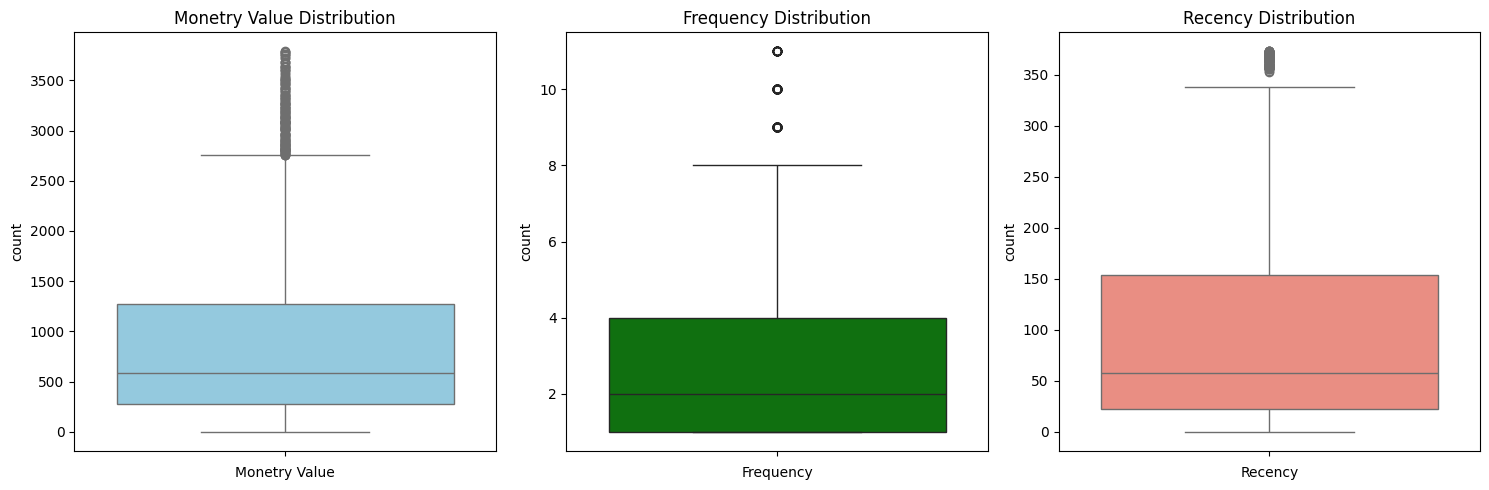

In [44]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data=non_outlier_df["MonetryValue"], color="skyblue")
plt.title("Monetry Value Distribution")
plt.xlabel("Monetry Value")
plt.ylabel("count")

plt.subplot(1,3,2)
sns.boxplot(data=non_outlier_df["Frequency"], color="green")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("count")

plt.subplot(1,3,3)
sns.boxplot(data=non_outlier_df["Recency"], color="salmon")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("count")

plt.tight_layout()
plt.show()

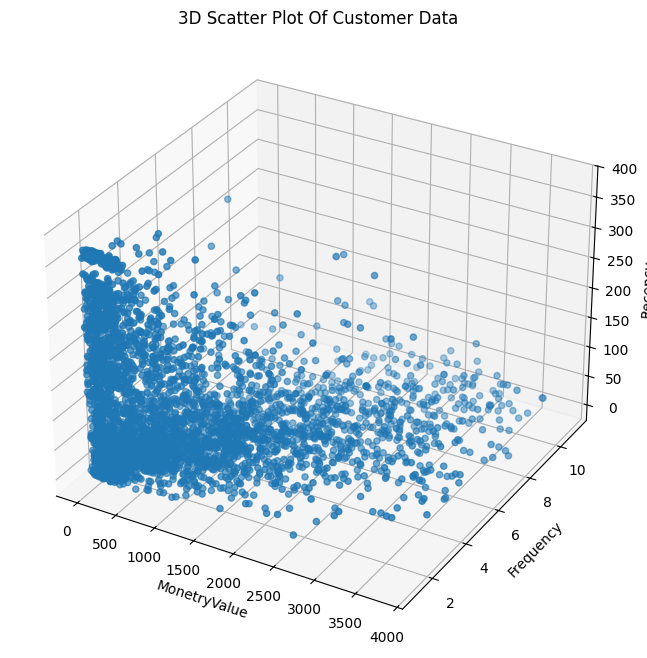

In [45]:
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection="3d")
scatter=ax.scatter(non_outlier_df["MonetryValue"], non_outlier_df["Frequency"], non_outlier_df["Recency"])
ax.set_xlabel("MonetryValue")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter Plot Of Customer Data")
plt.show()

In [46]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(non_outlier_df[["MonetryValue", "Frequency", "Recency"]])
scaled_data

array([[-0.88284831, -0.38531824,  0.68244986],
       [ 0.53737852, -0.38531824, -0.96932179],
       [-0.81213757, -0.83097766, -0.24539718],
       ...,
       [-0.62132263, -0.83097766,  2.01814175],
       [ 0.44323221, -0.38531824,  0.14205543],
       [ 1.72800052,  0.50600061, -0.81637997]])

In [47]:
scaled_data_df=pd.DataFrame(scaled_data, index=non_outlier_df.index, columns=["MonetryValue", "Frequency", "Recency"])
scaled_data_df

,MonetryValue,Frequency,Recency
0,-0.882848,-0.385318,0.682450
1,0.537379,-0.385318,-0.969322
2,-0.812138,-0.830978,-0.245397
3,1.636695,-0.385318,-0.561477
4,-0.714465,-0.830978,-0.887753
...,...,...,...
4280,-0.297131,1.397319,-0.816380
4281,-0.578859,-0.830978,-0.316770
4282,-0.621323,-0.830978,2.018142
4283,0.443232,-0.385318,0.142055


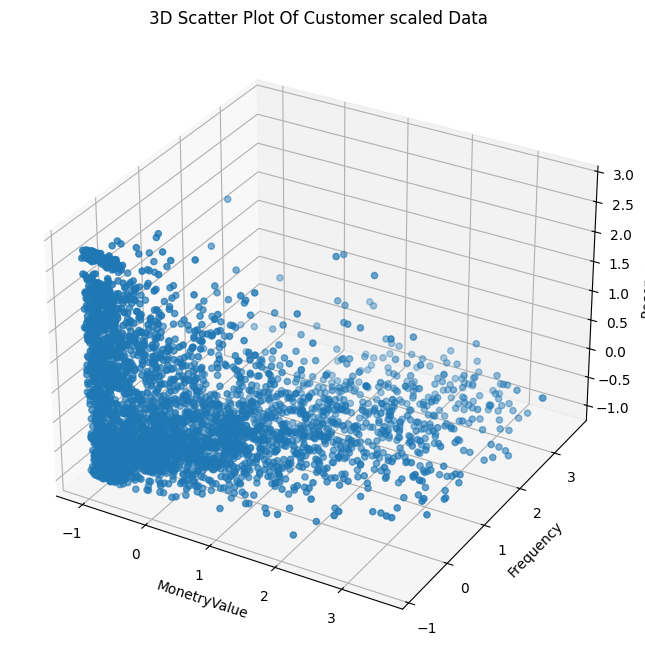

In [48]:
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection="3d")
scatter=ax.scatter(scaled_data_df["MonetryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])
ax.set_xlabel("MonetryValue")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter Plot Of Customer scaled Data")
plt.show()

**K-Means Clustering**

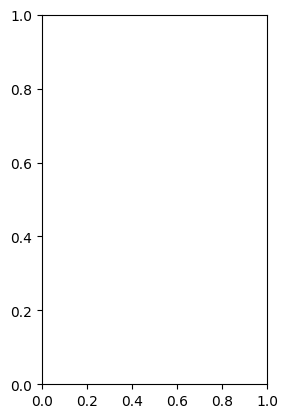

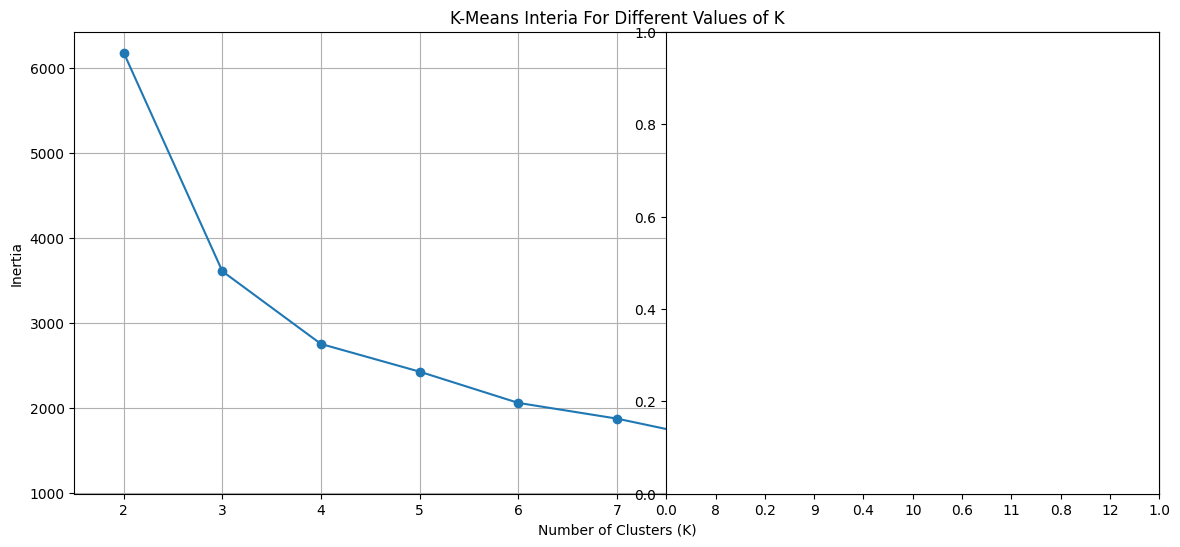

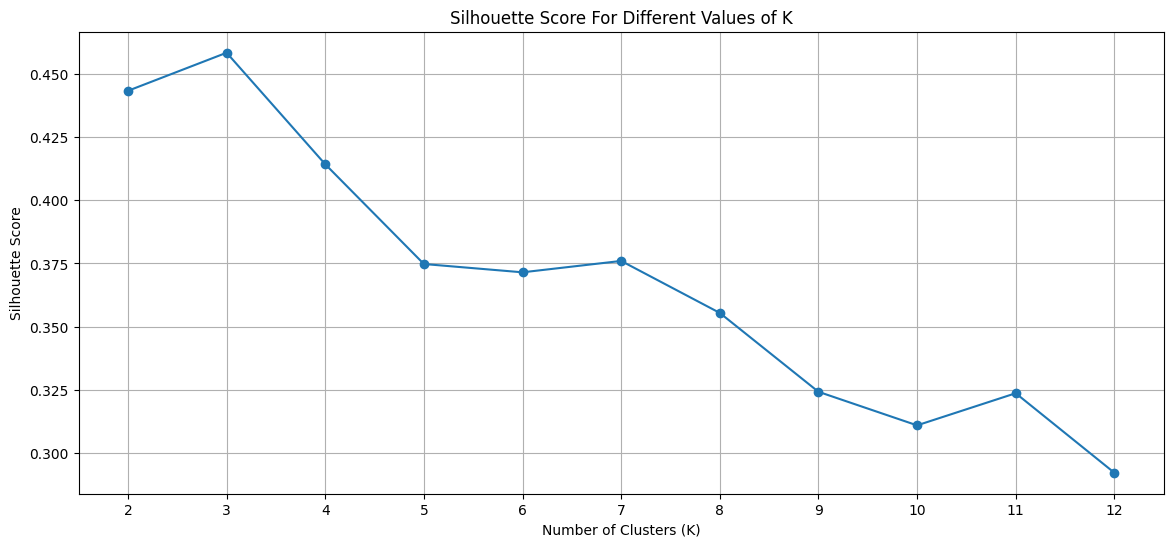

In [53]:
max_k=12
inertia=[]
silhouette_scores=[]
k_values=range(2,max_k+1)
for k in k_values:
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(scaled_data_df)
  sil_score=silhouette_score(scaled_data_df, kmeans.labels_)
  silhouette_scores.append(sil_score)
  inertia.append(kmeans.inertia_)
plt.subplot(1,2,1)
plt.figure(figsize=(14,6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.title("K-Means Interia For Different Values of K")

plt.subplot(1,2,2)
plt.figure(figsize=(14,6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score For Different Values of K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [56]:
kmeans=KMeans(n_clusters=4, random_state=42, max_iter=1000)
cluster_labels=kmeans.fit_predict(scaled_data_df)
cluster_labels

array([0, 1, 3, ..., 0, 1, 1], dtype=int32)

In [61]:
non_outlier_df["Cluster"]=cluster_labels
non_outlier_df

<ipython-input-61-034f658f809e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df["Cluster"]=cluster_labels


,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,163.41,2,2010-06-28 13:53:00,164,0
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1
2,12348.0,221.16,1,2010-09-27 14:59:00,73,3
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1
4,12351.0,300.93,1,2010-11-29 15:23:00,10,3
...,...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17,1
4281,18284.0,411.68,1,2010-10-04 11:33:00,66,3
4282,18285.0,377.00,1,2010-02-17 10:24:00,295,0
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111,1


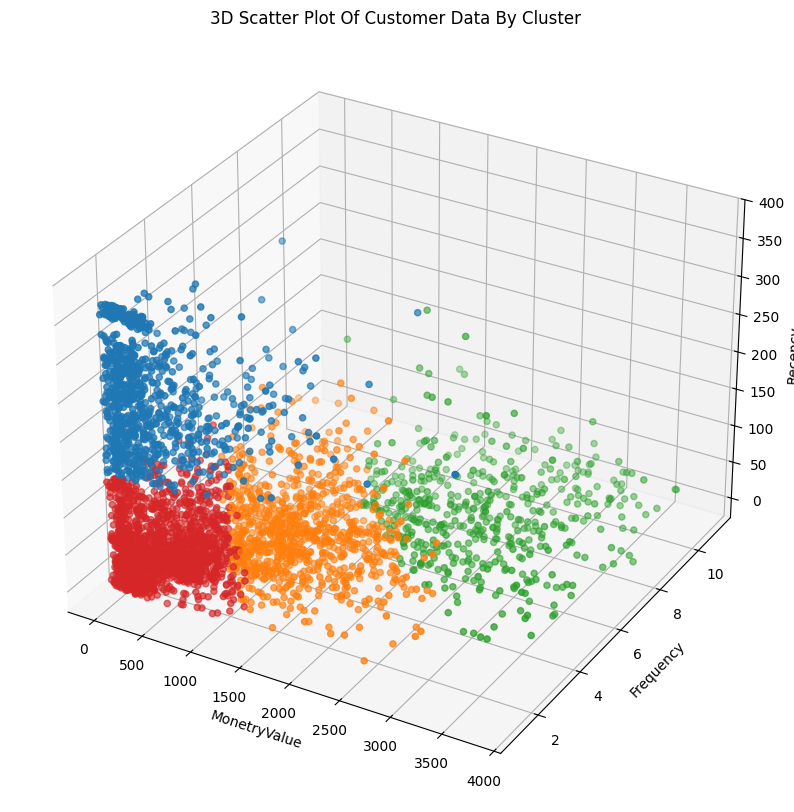

In [62]:
cluster_colors={
    0:'#1f77b4',
    1:'#ff7f0e',
    2:'#2ca02c',
    3:'#d62728'}
colors=non_outlier_df["Cluster"].map(cluster_colors)
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(projection="3d")
scatter=ax.scatter(non_outlier_df["MonetryValue"],
                   non_outlier_df["Frequency"],
                   non_outlier_df["Recency"], c=colors,
                   marker='o')
ax.set_xlabel("MonetryValue")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter Plot Of Customer Data By Cluster")
plt.show()


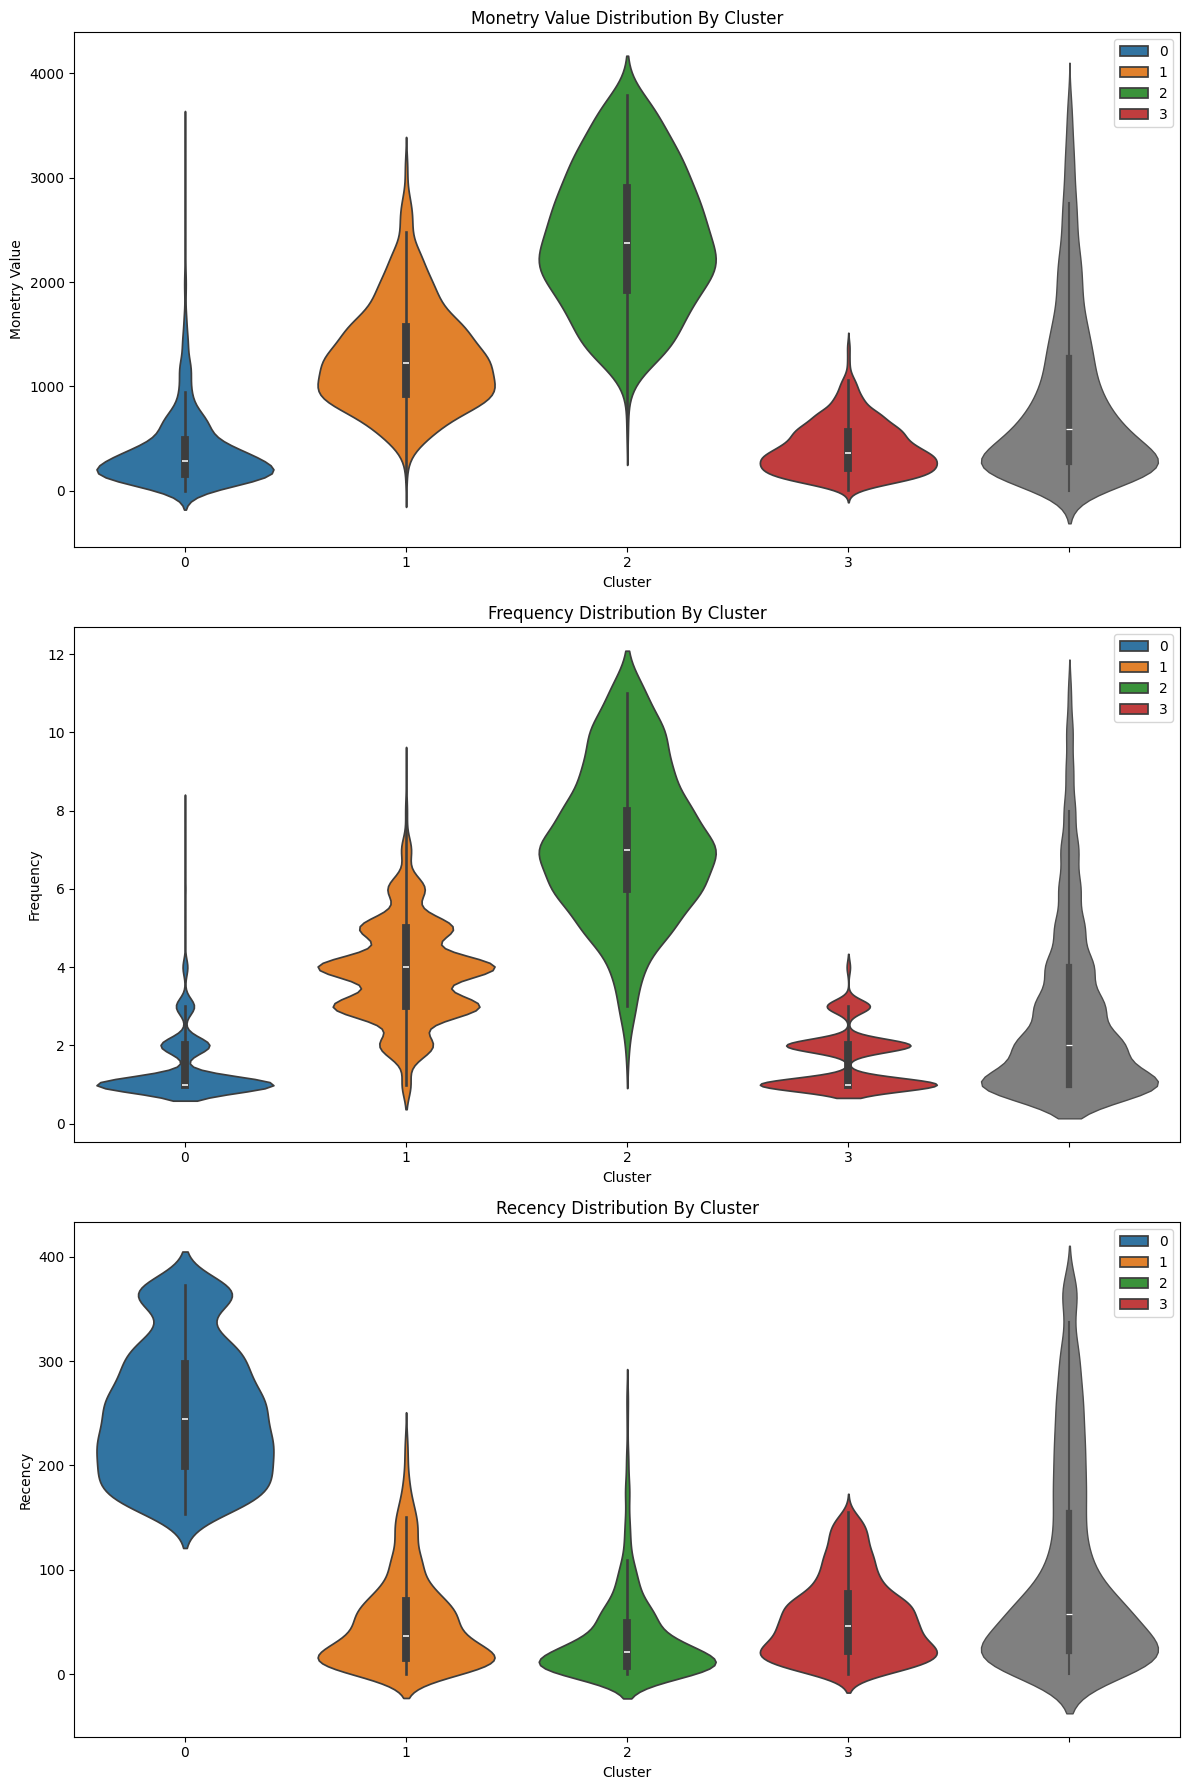

In [65]:
plt.figure(figsize=(12,18))
plt.subplot(3,1,1)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["MonetryValue"], palette=cluster_colors,hue=non_outlier_df["Cluster"])
sns.violinplot(y=non_outlier_df["MonetryValue"], color="gray", linewidth=1.0)
plt.title("Monetry Value Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Monetry Value")
plt.subplot(3,1,2)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["Frequency"], palette=cluster_colors,hue=non_outlier_df["Cluster"])
sns.violinplot(y=non_outlier_df["Frequency"], color="gray", linewidth=1.0)
plt.title("Frequency Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Frequency")
plt.subplot(3,1,3)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["Recency"], palette=cluster_colors,hue=non_outlier_df["Cluster"])
sns.violinplot(y=non_outlier_df["Recency"], color="gray", linewidth=1.0)
plt.title("Recency Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Recency")
plt.tight_layout()
plt.show()

In [72]:
overlap_indices=Monetary_outlier_df.index.intersection(Frequency_outlier_df.index)
Monetary_only_outliers=Monetary_outlier_df.drop(overlap_indices)
Frequency_only_outliers=Frequency_outlier_df.drop(overlap_indices)
Monetary_and_Frequency_outliers=Monetary_outlier_df.loc[overlap_indices]
Monetary_only_outliers["Cluster"]=-1
Frequency_only_outliers["Cluster"]=-2
Monetary_and_Frequency_outliers["Cluster"]=-3
outlier_cluster_df=pd.concat([Monetary_only_outliers, Frequency_only_outliers, Monetary_and_Frequency_outliers])
outlier_cluster_df

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7409.21,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


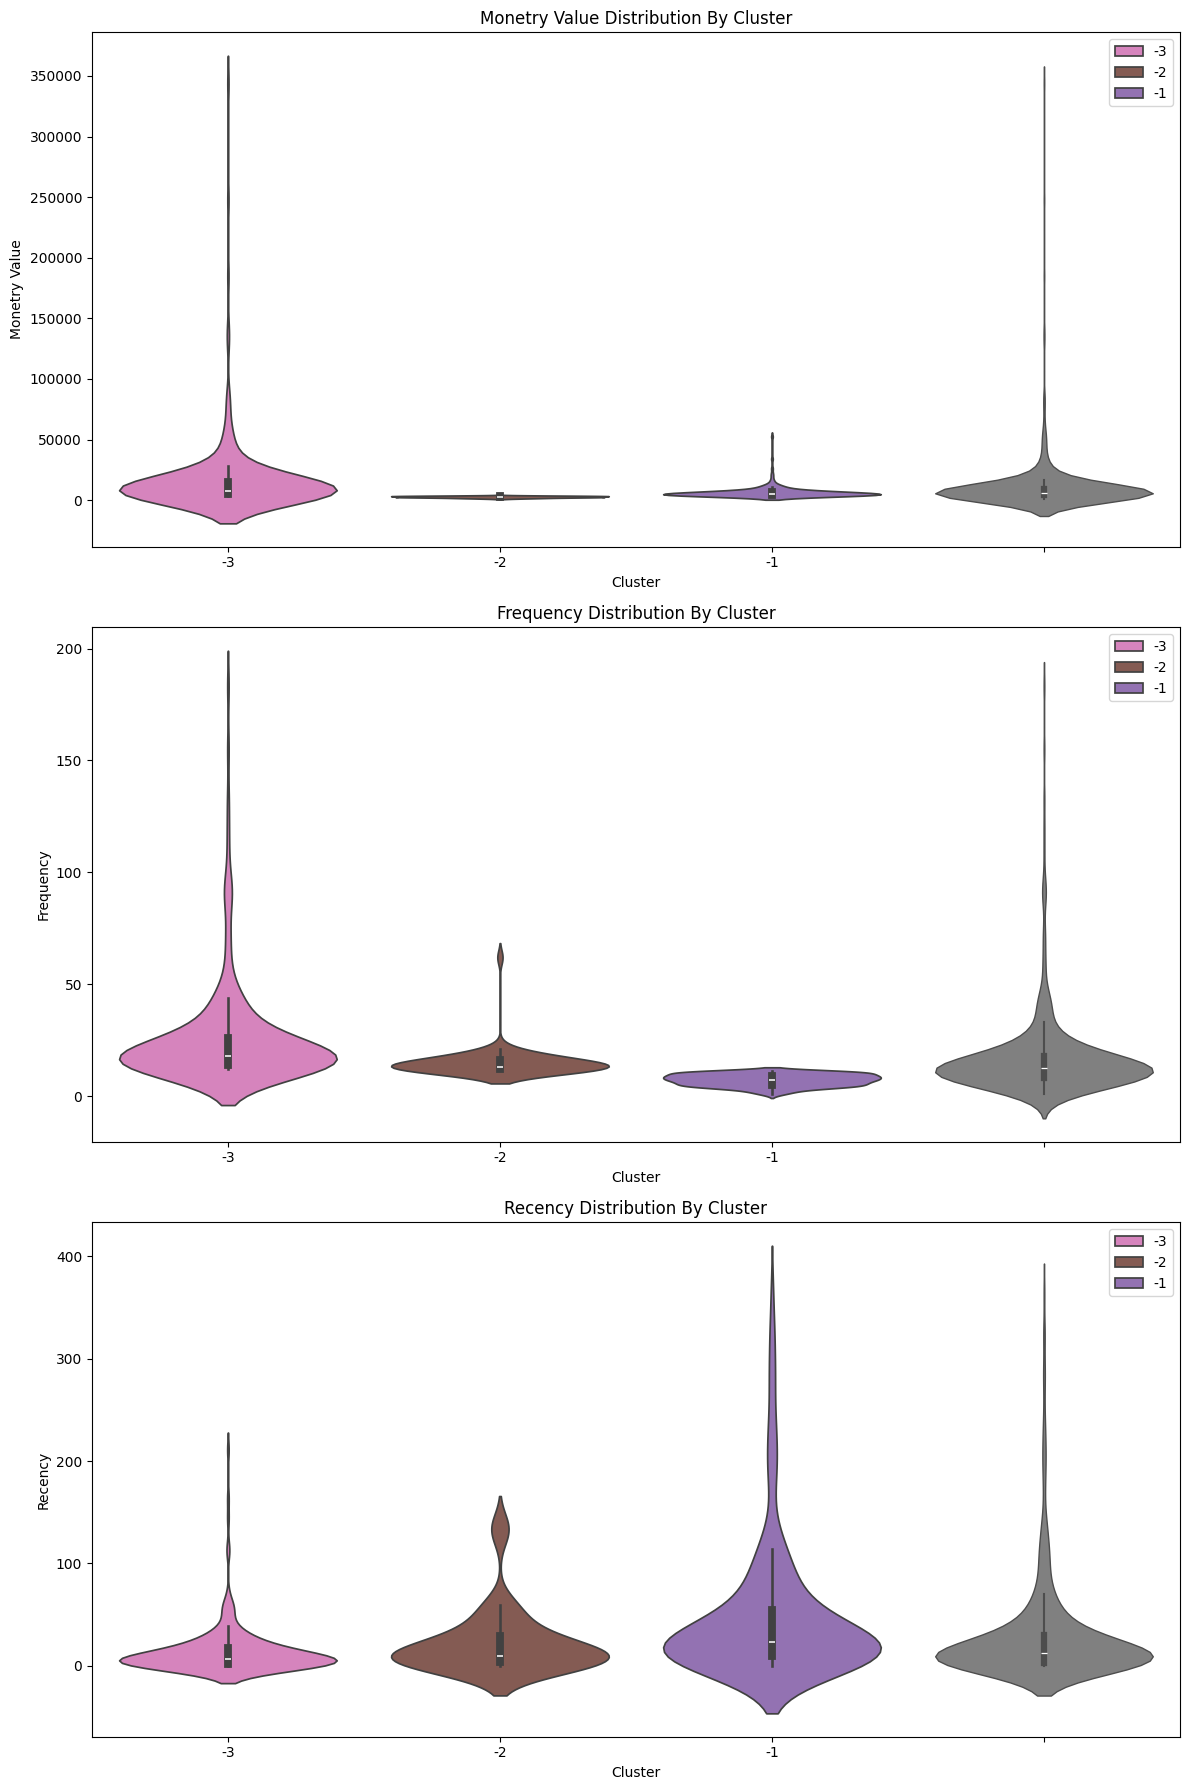

In [76]:
cluster_colors={ -1: '#9467bd',
                 -2: '#8c564b',
                 -3: '#e377c2'}


plt.figure(figsize=(12,18))
plt.subplot(3,1,1)
sns.violinplot(x=outlier_cluster_df["Cluster"], y=outlier_cluster_df["MonetryValue"], palette=cluster_colors,hue=outlier_cluster_df["Cluster"])
sns.violinplot(y=outlier_cluster_df["MonetryValue"], color="gray", linewidth=1.0)
plt.title("Monetry Value Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Monetry Value")
plt.subplot(3,1,2)
sns.violinplot(x=outlier_cluster_df["Cluster"], y=outlier_cluster_df["Frequency"], palette=cluster_colors,hue=outlier_cluster_df["Cluster"])
sns.violinplot(y=outlier_cluster_df["Frequency"], color="gray", linewidth=1.0)
plt.title("Frequency Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Frequency")
plt.subplot(3,1,3)
sns.violinplot(x=outlier_cluster_df["Cluster"], y=outlier_cluster_df["Recency"], palette=cluster_colors,hue=outlier_cluster_df["Cluster"])
sns.violinplot(y=outlier_cluster_df["Recency"], color="gray", linewidth=1.0)
plt.title("Recency Distribution By Cluster")
plt.xlabel("Cluster")
plt.ylabel("Recency")
plt.tight_layout()
plt.show()

In [79]:
cluster_labels={
    0:"RETAIN",
    1:"RE-ENGAGE",
    2:"NURTURE",
    3:"REWARD",
    -1:"PAMPER",
    -2:"UPSELL",
    -3:"DELIGHT"}
Full_Clustering_df=pd.concat([non_outlier_df, outlier_cluster_df])
Full_Clustering_df["ClusterLabel"]=Full_Clustering_df["Cluster"].map(cluster_labels)
Full_Clustering_df

,Customer ID,MonetryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.0,163.41,2,2010-06-28 13:53:00,164,0,RETAIN
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1,RE-ENGAGE
2,12348.0,221.16,1,2010-09-27 14:59:00,73,3,REWARD
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1,RE-ENGAGE
4,12351.0,300.93,1,2010-11-29 15:23:00,10,3,REWARD
...,...,...,...,...,...,...,...
4235,18223.0,7409.21,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


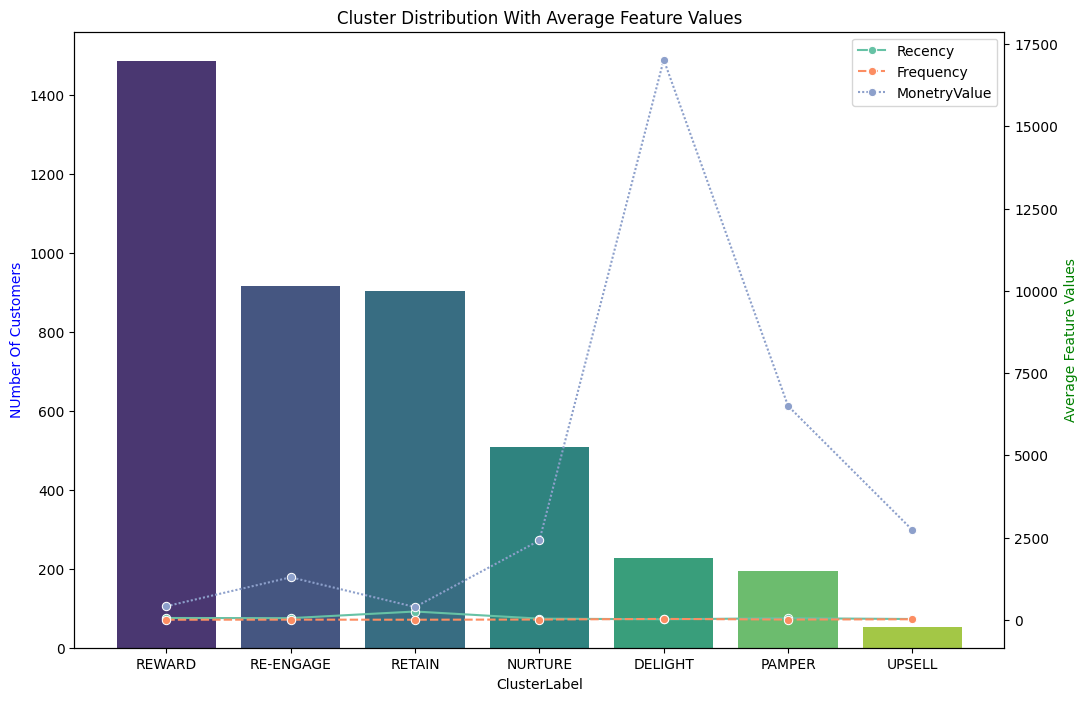

In [83]:
Cluster_counts=Full_Clustering_df["ClusterLabel"].value_counts()
Feature_means=Full_Clustering_df.groupby("ClusterLabel")[["Recency", "Frequency", "MonetryValue"]].mean()
fig,ax1=plt.subplots(figsize=(12,8))
sns.barplot(x=Cluster_counts.index, y=Cluster_counts.values, ax=ax1, palette="viridis", hue=Cluster_counts.index)
ax1.set_ylabel("NUmber Of Customers", color="b")
ax1.set_title("Cluster Distribution With Average Feature Values")
ax2=ax1.twinx()
sns.lineplot(data=Feature_means, ax=ax2, palette='Set2', marker="o")
ax2.set_ylabel("Average Feature Values", color="g")
plt.show()